In [4]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [5]:
import numpy as np
import pandas as pd 
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [6]:
df=pd.read_csv(r"credit_score.csv")

In [7]:
df.head()

,CUST_ID,INCOME,SAVINGS,DEBT,R_SAVINGS_INCOME,R_DEBT_INCOME,R_DEBT_SAVINGS,T_CLOTHING_12,T_CLOTHING_6,R_CLOTHING,...,R_EXPENDITURE_SAVINGS,R_EXPENDITURE_DEBT,CAT_GAMBLING,CAT_DEBT,CAT_CREDIT_CARD,CAT_MORTGAGE,CAT_SAVINGS_ACCOUNT,CAT_DEPENDENTS,CREDIT_SCORE,DEFAULT
0,C02COQEVYU,33269,0,532304,0.0000,16.0000,1.2000,1889,945,0.5003,...,0.0000,0.0625,High,1,0,0,0,0,444,1
1,C02OZKC0ZF,77158,91187,315648,1.1818,4.0909,3.4615,5818,111,0.0191,...,0.7692,0.2222,No,1,0,0,1,0,625,0
2,C03FHP2D0A,30917,21642,534864,0.7000,17.3000,24.7142,1157,860,0.7433,...,1.4286,0.0578,High,1,0,0,1,0,469,1
3,C03PVPPHOY,80657,64526,629125,0.8000,7.8000,9.7499,6857,3686,0.5376,...,1.2500,0.1282,High,1,0,0,1,0,559,0
4,C04J69MUX0,149971,1172498,2399531,7.8182,16.0000,2.0465,1978,322,0.1628,...,0.1163,0.0568,High,1,1,1,1,1,473,0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 87 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   CUST_ID                  1000 non-null   object 
 1   INCOME                   1000 non-null   int64  
 2   SAVINGS                  1000 non-null   int64  
 3   DEBT                     1000 non-null   int64  
 4   R_SAVINGS_INCOME         1000 non-null   float64
 5   R_DEBT_INCOME            1000 non-null   float64
 6   R_DEBT_SAVINGS           1000 non-null   float64
 7   T_CLOTHING_12            1000 non-null   int64  
 8   T_CLOTHING_6             1000 non-null   int64  
 9   R_CLOTHING               1000 non-null   float64
 10  R_CLOTHING_INCOME        1000 non-null   float64
 11  R_CLOTHING_SAVINGS       1000 non-null   float64
 12  R_CLOTHING_DEBT          1000 non-null   float64
 13  T_EDUCATION_12           1000 non-null   int64  
 14  T_EDUCATION_6            

In [9]:
df.isnull().sum()

CUST_ID                0
INCOME                 0
SAVINGS                0
DEBT                   0
R_SAVINGS_INCOME       0
                      ..
CAT_MORTGAGE           0
CAT_SAVINGS_ACCOUNT    0
CAT_DEPENDENTS         0
CREDIT_SCORE           0
DEFAULT                0
Length: 87, dtype: int64

In [10]:
#EDA

<Axes: xlabel='CREDIT_SCORE', ylabel='Count'>

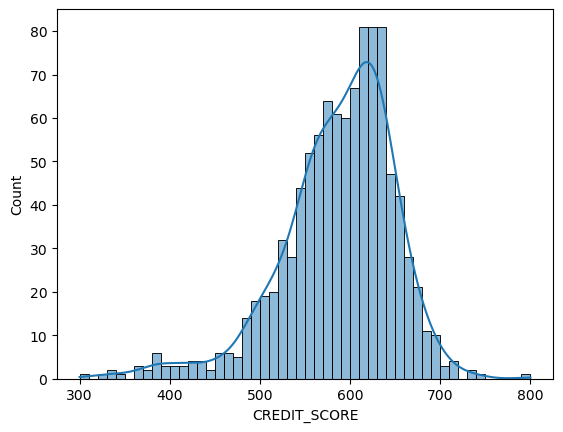

In [11]:
sns.histplot(df['CREDIT_SCORE'],bins=50,kde=True)

<Axes: >

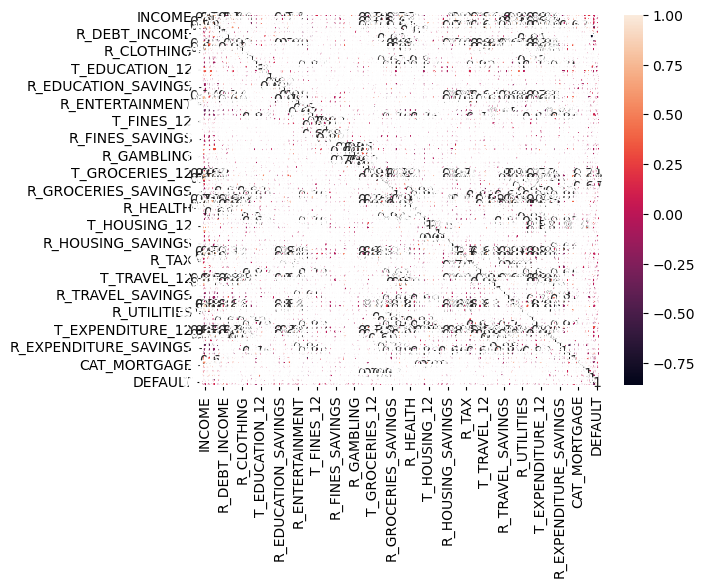

In [12]:
sns.heatmap(df.corr(numeric_only=True),annot=True)

In [13]:
df.columns

Index(['CUST_ID', 'INCOME', 'SAVINGS', 'DEBT', 'R_SAVINGS_INCOME',
       'R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'T_CLOTHING_12', 'T_CLOTHING_6',
       'R_CLOTHING', 'R_CLOTHING_INCOME', 'R_CLOTHING_SAVINGS',
       'R_CLOTHING_DEBT', 'T_EDUCATION_12', 'T_EDUCATION_6', 'R_EDUCATION',
       'R_EDUCATION_INCOME', 'R_EDUCATION_SAVINGS', 'R_EDUCATION_DEBT',
       'T_ENTERTAINMENT_12', 'T_ENTERTAINMENT_6', 'R_ENTERTAINMENT',
       'R_ENTERTAINMENT_INCOME', 'R_ENTERTAINMENT_SAVINGS',
       'R_ENTERTAINMENT_DEBT', 'T_FINES_12', 'T_FINES_6', 'R_FINES',
       'R_FINES_INCOME', 'R_FINES_SAVINGS', 'R_FINES_DEBT', 'T_GAMBLING_12',
       'T_GAMBLING_6', 'R_GAMBLING', 'R_GAMBLING_INCOME', 'R_GAMBLING_SAVINGS',
       'R_GAMBLING_DEBT', 'T_GROCERIES_12', 'T_GROCERIES_6', 'R_GROCERIES',
       'R_GROCERIES_INCOME', 'R_GROCERIES_SAVINGS', 'R_GROCERIES_DEBT',
       'T_HEALTH_12', 'T_HEALTH_6', 'R_HEALTH', 'R_HEALTH_INCOME',
       'R_HEALTH_SAVINGS', 'R_HEALTH_DEBT', 'T_HOUSING_12', 'T_HOUSING_6',
 

In [14]:
basic_cols=['CUST_ID', 'INCOME', 'SAVINGS','CAT_DEBT', 'CAT_CREDIT_CARD', 'DEBT','R_SAVINGS_INCOME','R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'R_TAX_DEBT', 'CREDIT_SCORE', 'DEFAULT']
cat_cols=['CAT_GAM', 'CBLING','CAT_DEBT', 'CAT_CREDIT_CARDAT_MORTGAGE', 'CAT_SAVINGS_ACCOUNT',
       'CAT_DEPENDENTS', 'CREDIT_SCORE', 'DEFAULT']
ratio_cols=['R_SAVINGS_INCOME','R_DEBT_INCOME', 'R_DEBT_SAVINGS',  'R_FINES',
       'R_FINES_INCOME','R_TAX', 'R_TAX_INCOME', 'R_TAX_SAVINGS',
       'R_TAX_DEBT','CREDIT_SCORE', 'DEFAULT']


<Axes: >

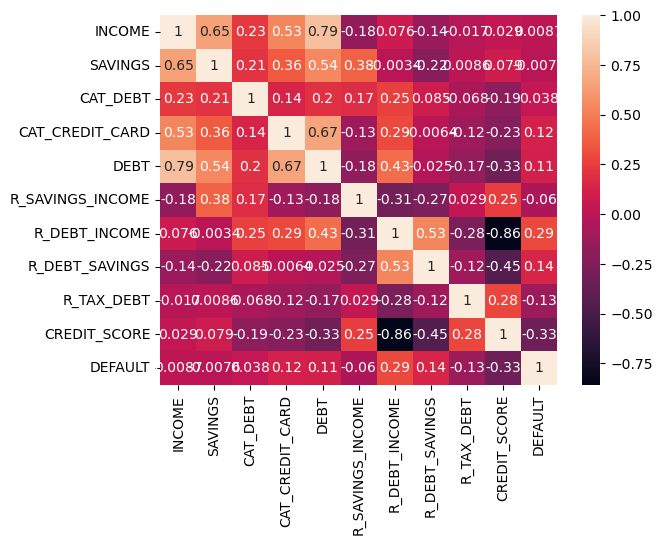

In [15]:
sns.heatmap(df[basic_cols].corr(numeric_only=True),annot=True)


In [16]:
sns.heatmap(df[cat_cols].corr(numeric_only=True),annot=True)

KeyError: "['CAT_GAM', 'CBLING', 'CAT_CREDIT_CARDAT_MORTGAGE'] not in index"

<Axes: >

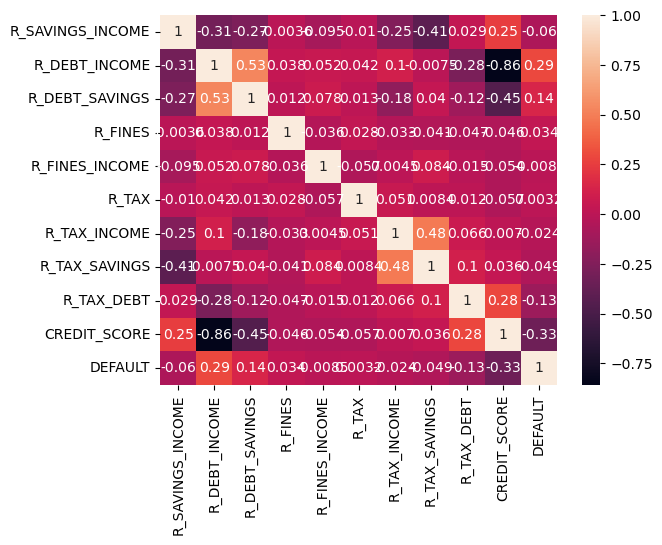

In [17]:
sns.heatmap(df[ratio_cols].corr(numeric_only=True),annot=True)

In [18]:
X=df[['INCOME', 'SAVINGS','CAT_DEBT', 'CAT_CREDIT_CARD', 'DEBT','R_SAVINGS_INCOME','R_DEBT_INCOME', 'R_DEBT_SAVINGS', 'R_TAX_DEBT']]
Y=df['CREDIT_SCORE']


In [19]:
from sklearn.preprocessing import StandardScaler

In [20]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error,mean_squared_error,r2_score



In [21]:
X_train,X_test,y_train,y_test = train_test_split(X, Y,test_size=0.33,random_state=42)

In [22]:
model = LinearRegression()
model.fit(X_train,y_train)


LinearRegression()

In [23]:
y_pred = model.predict(X_test)

In [24]:
r2 = r2_score(y_test,y_pred)
r2

0.7514430981796704

In [25]:
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import Lasso

In [26]:
log_model = LogisticRegression(max_iter=1000)
lasso_model = Lasso(alpha=1.0)


In [27]:

lasso_model.fit(X_train, y_train)


Lasso()

In [28]:
log_model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [29]:
lasso_predictions = lasso_model.predict(X_test)


In [30]:
log_predictions = log_model.predict(X_test)

In [31]:
from sklearn.metrics import accuracy_score

In [32]:
print(f"Lasso Regression R-squared: {r2_score(y_test, lasso_predictions)}")

Lasso Regression R-squared: 0.7495778001074866


In [33]:
print(f"Logistic Regression Accuracy: {accuracy_score(y_test, log_predictions)}")

Logistic Regression Accuracy: 0.024242424242424242


In [34]:
df2=df.drop(columns=['CUST_ID','CAT_GAMBLING'])

In [35]:
full_correlation_matrix = df2.corr()

In [36]:
correlations_with_target = full_correlation_matrix['CREDIT_SCORE']

In [37]:
print("Correlation of 'CREDIT_SCORE' with other columns (from full matrix):")
print(correlations_with_target)

Correlation of 'CREDIT_SCORE' with other columns (from full matrix):
INCOME                 0.029466
SAVINGS                0.078628
DEBT                  -0.327231
R_SAVINGS_INCOME       0.248420
R_DEBT_INCOME         -0.857900
                         ...   
CAT_MORTGAGE           0.017887
CAT_SAVINGS_ACCOUNT    0.128868
CAT_DEPENDENTS        -0.156451
CREDIT_SCORE           1.000000
DEFAULT               -0.333092
Name: CREDIT_SCORE, Length: 85, dtype: float64


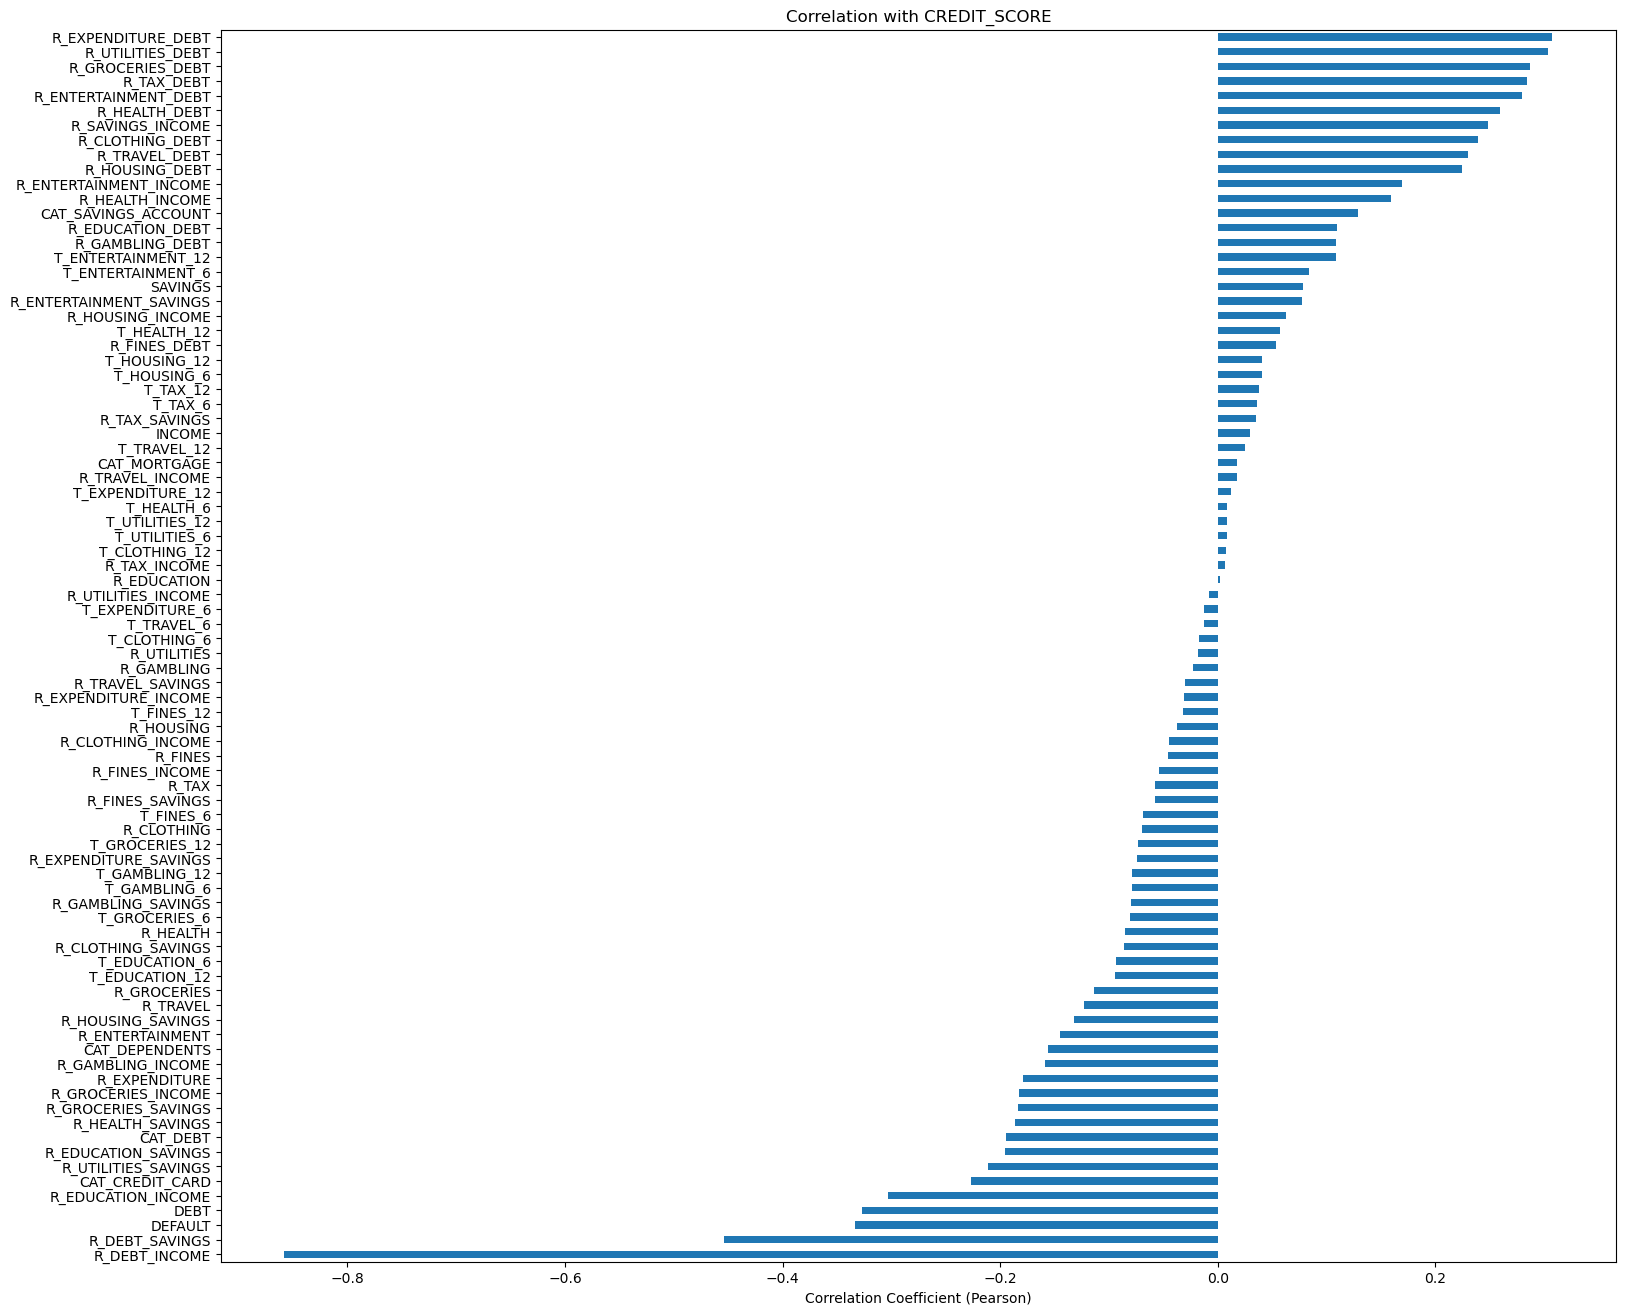

In [38]:
plt.figure(figsize=(18, 16))
correlations_with_target.drop('CREDIT_SCORE').sort_values().plot(kind='barh')
plt.title('Correlation with CREDIT_SCORE')
plt.xlabel('Correlation Coefficient (Pearson)')
plt.show()

In [39]:
correlation_series = df2.corrwith(df['CREDIT_SCORE']).abs().sort_values(ascending=False)

In [40]:
top_features = correlation_series[1:46].index.tolist()

In [41]:
top_features

['R_DEBT_INCOME',
 'R_DEBT_SAVINGS',
 'DEFAULT',
 'DEBT',
 'R_EXPENDITURE_DEBT',
 'R_UTILITIES_DEBT',
 'R_EDUCATION_INCOME',
 'R_GROCERIES_DEBT',
 'R_TAX_DEBT',
 'R_ENTERTAINMENT_DEBT',
 'R_HEALTH_DEBT',
 'R_SAVINGS_INCOME',
 'R_CLOTHING_DEBT',
 'R_TRAVEL_DEBT',
 'CAT_CREDIT_CARD',
 'R_HOUSING_DEBT',
 'R_UTILITIES_SAVINGS',
 'R_EDUCATION_SAVINGS',
 'CAT_DEBT',
 'R_HEALTH_SAVINGS',
 'R_GROCERIES_SAVINGS',
 'R_GROCERIES_INCOME',
 'R_EXPENDITURE',
 'R_ENTERTAINMENT_INCOME',
 'R_HEALTH_INCOME',
 'R_GAMBLING_INCOME',
 'CAT_DEPENDENTS',
 'R_ENTERTAINMENT',
 'R_HOUSING_SAVINGS',
 'CAT_SAVINGS_ACCOUNT',
 'R_TRAVEL',
 'R_GROCERIES',
 'R_EDUCATION_DEBT',
 'R_GAMBLING_DEBT',
 'T_ENTERTAINMENT_12',
 'T_EDUCATION_12',
 'T_EDUCATION_6',
 'R_CLOTHING_SAVINGS',
 'R_HEALTH',
 'T_ENTERTAINMENT_6',
 'T_GROCERIES_6',
 'R_GAMBLING_SAVINGS',
 'SAVINGS',
 'T_GAMBLING_6',
 'T_GAMBLING_12']

In [42]:
X3_top = df2[top_features]
Y3 = df2['CREDIT_SCORE']
scaler = StandardScaler()


In [43]:
X_train, X_test, y_train, y_test = train_test_split(X3_top,Y3,test_size=0.2,random_state=42,shuffle=True        
)


In [44]:
model = LinearRegression()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [45]:
model.fit(X_train_scaled, y_train)

LinearRegression()

In [46]:
predictions = model.predict(X_test_scaled)

In [47]:
score = r2_score(y_test, predictions)
print(f"\nModel R-squared score on test set: {score*100:.2f}%")


Model R-squared score on test set: 79.47%


In [48]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import r2_score

# Using your original, non-scaled X_train/X_test data (RF doesn't need scaling)

rf_regressor = RandomForestRegressor(n_estimators=100, random_state=42)
rf_regressor.fit(X_train, y_train)

y_pred_rfr = rf_regressor.predict(X_test)

r2 = r2_score(y_test, y_pred_rfr)
print(f"Random Forest Regressor R-squared Score: {r2*100:.2f}%")


Random Forest Regressor R-squared Score: 76.96%


In [49]:
# Import the necessary library
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

# Assuming X_train, y_train, X_test, y_test are already defined and cleaned

# 1. Initialize the Decision Tree Classifier model
# You can adjust parameters like max_depth later for tuning
dt_classifier = DecisionTreeClassifier(random_state=42)

# 2. Fit the model to your training data
print("Fitting Decision Tree Classifier...")
dt_classifier.fit(X_train, y_train)
print("Fitting complete.")

# 3. Make predictions on the test set
y_pred_dt = dt_classifier.predict(X_test)

# 4. Evaluate the model's accuracy
accuracy = accuracy_score(y_test, y_pred_dt)
print(f"\nDecision Tree Classifier Accuracy: {accuracy*100:.2f}%")


Fitting Decision Tree Classifier...
Fitting complete.

Decision Tree Classifier Accuracy: 1.00%
